# 1. Import Data

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
path = '/content/drive/MyDrive/Books RecSys Dataset (API Call)/books_fully_healed.csv'
if os.path.exists(path):
    print("✅ Đã tìm thấy dữ liệu trên Drive. Bắt đầu giai đoạn EDA và Modeling!")
    df = pd.read_csv(path, low_memory=False)
else:
    print("❌ Không tìm thấy file. Hãy kiểm tra lại đường dẫn trên Drive của bạn.")

df.head(5)

✅ Đã tìm thấy dữ liệu trên Drive. Bắt đầu giai đoạn EDA và Modeling!


,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0


# 2. EDA & Preprocessing

## 2.1 EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6810 entries, 0 to 6809
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   isbn13          6810 non-null   int64  
 1   isbn10          6810 non-null   object 
 2   title           6810 non-null   object 
 3   subtitle        2393 non-null   object 
 4   authors         6757 non-null   object 
 5   categories      6731 non-null   object 
 6   thumbnail       6595 non-null   object 
 7   description     6693 non-null   object 
 8   published_year  6806 non-null   float64
 9   average_rating  6773 non-null   float64
 10  num_pages       6788 non-null   float64
 11  ratings_count   6773 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 638.6+ KB


In [ ]:
df.describe()

,isbn13,published_year,average_rating,num_pages,ratings_count
count,6.810000e+03,6806.000000,6773.000000,6788.000000,6.773000e+03
mean,9.780677e+12,1998.629445,3.933490,348.481880,2.105044e+04
std,6.068911e+08,10.484119,0.331575,242.976996,1.375611e+05
min,9.780002e+12,1853.000000,0.000000,0.000000,0.000000e+00
25%,9.780330e+12,1996.000000,3.770000,208.000000,1.580000e+02
50%,9.780553e+12,2002.000000,3.960000,304.000000,1.015000e+03
75%,9.780810e+12,2005.000000,4.130000,420.000000,5.986000e+03
max,9.789042e+12,2019.000000,5.000000,3342.000000,5.629932e+06


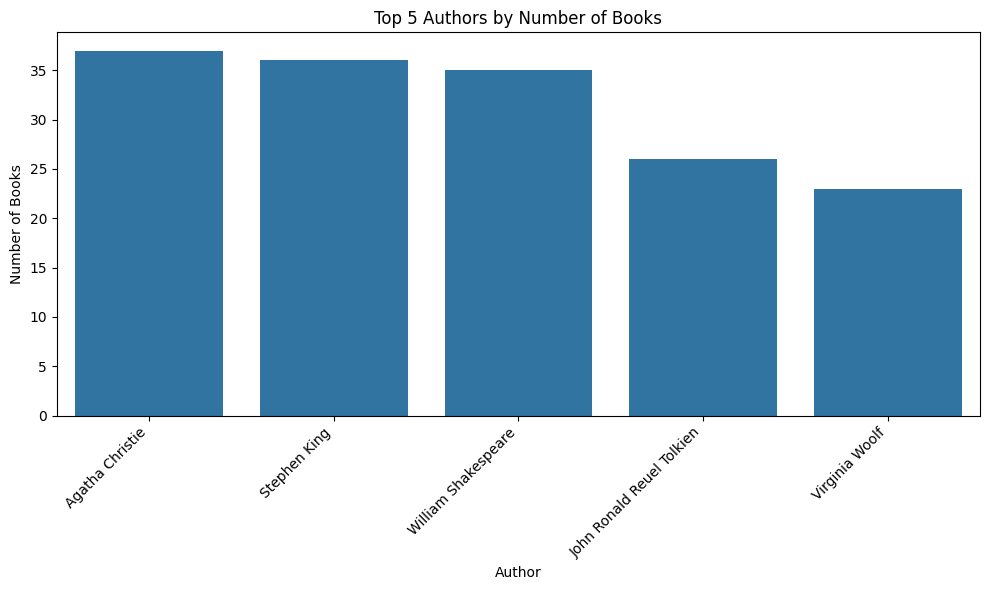

In [ ]:
# Đếm số sách cho mỗi tác giả
author_counts = df['authors'].value_counts()

# Chọn top 5 tác giả (loại bỏ giá trị rỗng nếu có)
top_authors = author_counts[author_counts.index != ''].head(5)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x=top_authors.index, y=top_authors.values)
plt.title('Top 5 Authors by Number of Books')
plt.xlabel('Author')
plt.ylabel('Number of Books')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

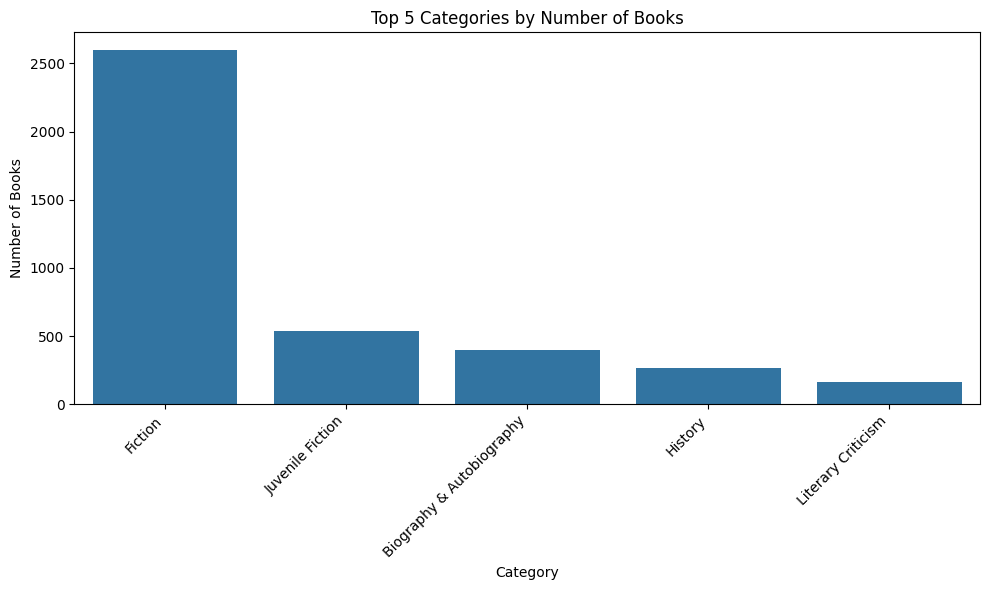

In [ ]:
# Đếm số sách cho mỗi thể loại
category_counts = df['categories'].value_counts()

# Chọn top 5 thể loại (loại bỏ giá trị rỗng nếu có)
top_categories = category_counts[category_counts.index != ''].head(5)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.index, y=top_categories.values)
plt.title('Top 5 Categories by Number of Books')
plt.xlabel('Category')
plt.ylabel('Number of Books')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Axes: xlabel='published_year', ylabel='Count'>

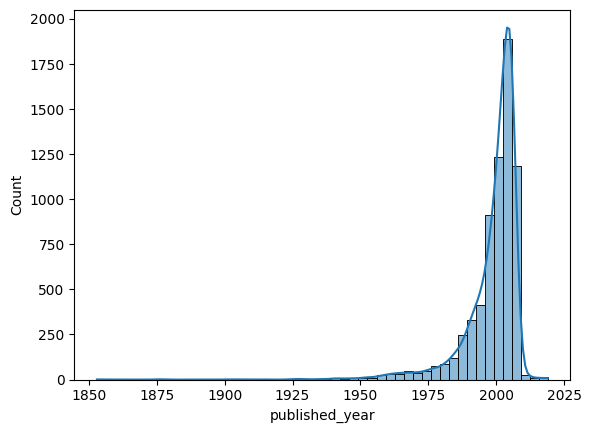

In [ ]:
sns.histplot(df['published_year'], bins=50, kde=True)

In [ ]:
df.sort_values(by='average_rating' , ascending= False )[['title' ,'average_rating']].head(10)

,title,average_rating
6738,Insights,5.0
6671,The Diamond Color Meditation,5.0
4281,Middlesex Borough,5.0
5972,Ecuador Nature Guide,5.0
1441,Fanning the Flame,5.0
6720,The Irish Anatomist,5.0
4306,Bill Gates,5.0
4284,Lake Orion,5.0
3580,Colossians and Philemon,5.0
1779,The Fellowship of the Ring,5.0


In [ ]:
df.sort_values(by='ratings_count', ascending = False)[['title' , 'ratings_count']].head(10)

,title,ratings_count
2698,Harry Potter and the Sorcerer's Stone (Book 1),5629932.0
1643,Twilight,4367341.0
3741,"The Hobbit, Or, There and Back Again",2364968.0
5898,Angels & Demons,2279854.0
2710,Harry Potter and the Prisoner of Azkaban (Book 3),2149872.0
2661,Harry Potter and the Chamber of Secrets (Book 2),2115562.0
3745,The Fellowship of the Ring,2009749.0
2676,Harry Potter and the Order of the Phoenix (Boo...,1996446.0
2723,Harry Potter and the Half-Blood Prince (Book 6),1944099.0
738,Lord of the Flies,1861140.0


## 2.2 Preprocessing

Handle Duplicates

In [ ]:
initial_rows = len(df)
df.drop_duplicates(subset=['title'], keep='first', inplace=True)
print(f"Số lượng hàng ban đầu: {initial_rows}")
print(f"Số lượng sách sau khi loại bỏ trùng lặp và tiền xử lý: {len(df)}")

Số lượng hàng ban đầu: 6810
Số lượng sách sau khi loại bỏ trùng lặp và tiền xử lý: 6398


Handle Missing Values

In [ ]:
missing_percentage = df.isnull().sum() * 100 / len(df)
print(missing_percentage.sort_values(ascending=False))

subtitle          64.520163
thumbnail          2.891529
description        1.656768
categories         1.109722
authors            0.750234
average_rating     0.453267
ratings_count      0.453267
num_pages          0.218818
published_year     0.062520
title              0.000000
isbn13             0.000000
isbn10             0.000000
dtype: float64


Strategy :
- Drop categories (1.16%) and description (1.71%)
- Impute average_rating and ratings_count
- Subtitle (64.86%): This is a very high percentage of missing entries, but we should NOT drop this column. Many books in the world don't have subtitles. Solution: Fill it with an empty string "".
- Thumbnail (3.15%): Fill it with the default image link (Placeholder URL) to avoid interface errors when uploading to the Web App later.
- Authors (0.77%) & Published_Year (0.05%): This percentage is too small; we can drop it along with the description, or fill it with "Unknown".

In [ ]:
import re
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # 1. Xóa sạch các thẻ HTML (Cực kỳ quan trọng với description)
    text = re.sub(r'<.*?>', ' ', text)
    # 2. Thay thế các ký tự xuống dòng, tab bằng khoảng trắng
    text = re.sub(r'[\r\n\t]+', ' ', text)
    #3. Gom các khoảng trắng liền nhau thành 1 khoảng trắng duy nhất và cắt hai đầu
    text = re.sub(r'\s+', ' ', text).strip()
    # KHÔNG lower(), KHÔNG xóa dấu câu để giữ nguyên ngữ cảnh cho AI
    return text

def Preprocessing(df):
  df['subtitle'] = df['subtitle'].fillna('') # Added .fillna('') as subtitle was being assigned to itself
  df['thumbnail'] = df['thumbnail'].fillna("https://via.placeholder.com/150x200.png?text=No+Cover")
  df['authors'] = df['authors'].fillna("Unknown Author")

  # 2. Nội suy (Imputation) các cột Số (Numerical)
  # Điền trung vị cho rating và số trang để tránh nhiễu do outliers
  df['average_rating'] = df['average_rating'].fillna(df['average_rating'].median())
  df['num_pages'] = df['num_pages'].fillna(df['num_pages'].median())
  # Điền 0 cho số lượt vote (vì không có data = không ai vote)
  df['ratings_count'] = df['ratings_count'].fillna(0)

  # 3. CHỐT CHẶN CỐT LÕI (Drop Missing values cho Text Features)
  # Loại bỏ vĩnh viễn sách thiếu Description và Categories theo đúng chiến lược
  df = df.dropna(subset=['description', 'categories'])

  text_cols = ['title', 'subtitle', 'authors', 'description', 'categories']
  for col in text_cols:
        df[col] = df[col].apply(clean_text)

  df = df.reset_index(drop=True)
  return df

In [ ]:
df = Preprocessing(df)
df.info()

/tmp/ipykernel_1482/2365848602.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].apply(clean_text)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6244 entries, 0 to 6243
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   isbn13          6244 non-null   int64  
 1   isbn10          6244 non-null   object 
 2   title           6244 non-null   object 
 3   subtitle        6244 non-null   object 
 4   authors         6244 non-null   object 
 5   categories      6244 non-null   object 
 6   thumbnail       6244 non-null   object 
 7   description     6244 non-null   object 
 8   published_year  6242 non-null   float64
 9   average_rating  6244 non-null   float64
 10  num_pages       6244 non-null   float64
 11  ratings_count   6244 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 585.5+ KB


In [ ]:
df.head(5)

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0


## 2.2 Feature Engineering

Assign a prefix to each data field, then create a `content_bundle` column to put all text content into a single field.

In [ ]:
def create_content_bundle(row):
    # Gắn nhãn rõ ràng để dẫn đường cho cơ chế Attention của AI
    title = f"Title: {row['title']}"
    author = f"Author: {row['authors']}"
    category = f"Category: {row['categories']}"
    description = f"Description: {row['description']}"

    # Nối lại với nhau, phân cách bằng dấu chấm để tạo thành các mệnh đề rõ ràng
    return f"{title}. {author}. {category}. {description}"

# Áp dụng hàm lên toàn bộ DataFrame
df['content_bundle'] = df.apply(create_content_bundle, axis=1)

print(f" Đã tạo xong cột 'content_bundle'.")
print(" XEM THỬ MỘT VÍ DỤ MÀ AI SẼ ĐỌC:")
print(df['content_bundle'].iloc[0]) # In thử dòng đầu tiên ra để kiểm tra

 Đã tạo xong cột 'content_bundle'.
 XEM THỬ MỘT VÍ DỤ MÀ AI SẼ ĐỌC:
Title: Gilead. Author: Marilynne Robinson. Category: Fiction. Description: A NOVEL THAT READERS and critics have been eagerly anticipating for over a decade, Gilead is an astonishingly imagined story of remarkable lives. John Ames is a preacher, the son of a preacher and the grandson (both maternal and paternal) of preachers. It’s 1956 in Gilead, Iowa, towards the end of the Reverend Ames’s life, and he is absorbed in recording his family’s story, a legacy for the young son he will never see grow up. Haunted by his grandfather’s presence, John tells of the rift between his grandfather and his father: the elder, an angry visionary who fought for the abolitionist cause, and his son, an ardent pacifist. He is troubled, too, by his prodigal namesake, Jack (John Ames) Boughton, his best friend’s lost son who returns to Gilead searching for forgiveness and redemption. Told in John Ames’s joyous, rambling voice that finds bea

## 2.3 Embedding Data

In [ ]:
max_len = df['content_bundle'].str.len().max()
print(f"Maximum length of content bundle: {max_len} characters")

Maximum length of content bundle: 5872 characters


In [ ]:
!pip install einops

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 81.6 MB/s eta 0:00:00


In [ ]:
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
# Nạp lại dữ liệu (giả sử bạn đã chạy xong bước Bundle)
texts = df['content_bundle'].tolist()

print("\n Đang tải mô hình AI Long-Context (Nomic-Embed-Text)...")
# Tham số trust_remote_code=True là bắt buộc để tải các model thế hệ mới từ Hugging Face
model = SentenceTransformer('nomic-ai/nomic-embed-text-v1.5', trust_remote_code=True)

# Báo cho mô hình biết chúng ta đang dùng nó để làm hệ thống tìm kiếm (Search)
prompt_prefix = "search_document: "
texts_with_prefix = [prompt_prefix + text for text in texts]

print(f" Bắt đầu nhúng {len(texts)} văn bản (Không bị cắt cụt đuôi)...")
embeddings = model.encode(texts_with_prefix, show_progress_bar=True)
embeddings = np.array(embeddings).astype('float32')

print("\n Đang xây dựng bộ não tìm kiếm FAISS...")
dimension = embeddings.shape[1] # Lúc này sẽ là 768 chiều thay vì 384
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)


 Đang tải mô hình AI Long-Context (Nomic-Embed-Text)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/140 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

 Bắt đầu nhúng 6244 văn bản (Không bị cắt cụt đuôi)...


Batches:   0%|          | 0/196 [00:00<?, ?it/s]


 Đang xây dựng bộ não tìm kiếm FAISS...


In [ ]:
faiss.write_index(index, "books_index_nomic.faiss")
df.to_csv("books_metadata.csv", index=False ,encoding='utf-8-sig')